In [5]:
# --- Install dependencies if needed (run once) ---
# %pip install -q matplotlib imageio[ffmpeg]

import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

# ---------- Configuration ----------
JSON_PATH = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_exact_ll/bpe_exact_ll-telemetry.json"
TOP_K = 100                   # number of top-scoring pairs to show per snapshot
FPS = 4                       # frames per second in the animation
DPI = 120                     # output video DPI
OUTPUT_PATH = str(Path(JSON_PATH).with_name(f"top{TOP_K}_scores.mp4"))
# -----------------------------------

# Load telemetry JSON
with open(JSON_PATH, "r") as f:
    telemetry = json.load(f)

snapshots = telemetry.get("score_snapshots", [])
if not snapshots:
    raise RuntimeError("No 'score_snapshots' found; make sure you trained with score_snapshot_every>0 and saved telemetry.")

# Prepare frames: for each snapshot, take top-K scores by 'score'
frames = []
global_max = 0.0
for snap in snapshots:
    items = snap.get("items", [])
    # sort by score descending and take top-K
    top_items = sorted(items, key=lambda it: float(it.get("score", 0.0)), reverse=True)[:TOP_K]
    print("max and min scores in snapshot step {}: {:.6f}, {:.6f}".format(snap.get("step", 0),
                                                                        float(np.max([float(it.get("score", 0.0)) for it in top_items])) if top_items else 0.0,
                                                                        float(np.min([float(it.get("score", 0.0)) for it in top_items])) if top_items else 0.0))
    scores = np.array([float(it.get("score", 0.0)) for it in top_items], dtype=float)
    frames.append((int(snap.get("step", 0)), scores))
    if scores.size:
        global_max = max(global_max, float(np.max(scores)))

if not frames or all(len(s) == 0 for _, s in frames):
    raise RuntimeError("All snapshots have empty 'items'; nothing to animate.")

max_bars = min(TOP_K, max(len(s) for _, s in frames))

# Build animation
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 6))
# ax.set_yscale('log')
x = np.arange(max_bars)
bars = ax.bar(x, np.zeros_like(x))
ax.set_xlim(-0.5, max_bars - 0.5)
ax.set_ylim(0, max(1.0, global_max * 1.05))
ax.set_xlabel("Top-N candidate index")   # no text labels for pairs, as requested
ax.set_ylabel("Score")

title = ax.set_title("Top-{} candidate scores — step …".format(max_bars))
plt.tight_layout()

def init():
    for b in bars:
        b.set_height(0.0)
    title.set_text("")
    return [*bars, title]

def update(frame_idx):
    step, scores = frames[frame_idx]
    for i, b in enumerate(bars):
        h = float(scores[i]) if i < len(scores) else 0.0
        b.set_height(h)
    title.set_text(f"Top-{max_bars} candidate scores — snapshot @ step {step}")
    return [*bars, title]

anim = animation.FuncAnimation(
    fig, update, init_func=init, frames=len(frames),
    interval=1000 / FPS, blit=True, repeat=False
)

# Save as MP4 (fallback to GIF if ffmpeg is unavailable)
try:
    from matplotlib.animation import FFMpegWriter
    writer = FFMpegWriter(fps=FPS, bitrate=2000)
    anim.save(OUTPUT_PATH, writer=writer, dpi=DPI)
    print(f"✅ MP4 saved to: {OUTPUT_PATH}")
except Exception as e:
    print("ffmpeg not found or error during MP4 export, falling back to GIF:", e)
    gif_path = str(Path(OUTPUT_PATH).with_suffix(".gif"))
    from matplotlib.animation import PillowWriter
    anim.save(gif_path, writer=PillowWriter(fps=FPS))
    print(f"🎞️ GIF saved to: {gif_path}")

plt.close(fig)

max and min scores in snapshot step 1000: 527487.694034, 55563.290507
max and min scores in snapshot step 2000: 511541.280357, 34627.301566
max and min scores in snapshot step 3000: 436216.618449, 24755.157942
max and min scores in snapshot step 4000: 440164.003871, 18793.412693
max and min scores in snapshot step 5000: 474401.575918, 15152.595226
max and min scores in snapshot step 6000: 465173.972696, 12648.548793
max and min scores in snapshot step 7000: 473804.262919, 11494.364120
max and min scores in snapshot step 8000: 473254.784938, 9666.025276
max and min scores in snapshot step 9000: 476000.332170, 8862.918163
max and min scores in snapshot step 10000: 488504.241311, 8203.648347
max and min scores in snapshot step 11000: 489982.541334, 7373.229634
max and min scores in snapshot step 12000: 488053.659561, 7016.546024
max and min scores in snapshot step 13000: 490737.724132, 6402.258842
max and min scores in snapshot step 14000: 97323.134104, 5346.046178
max and min scores in s

In [3]:
!pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp310-cp310-macosx_11_0_arm64.whl (10.8 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


Snapshots: 49
First 5:
  step=  1000  n_items=  49804  max_score=42109
  step=  2000  n_items=  49783  max_score=18276
  step=  3000  n_items=  49697  max_score=11209
  step=  4000  n_items=  49644  max_score=7558
  step=  5000  n_items=  49568  max_score=5588
  step=  6000  n_items=  49507  max_score=4330
  step=  7000  n_items=  49454  max_score=3460
  step=  8000  n_items=  49417  max_score=2837
  step=  9000  n_items=  49354  max_score=2383
  step= 10000  n_items=  49291  max_score=2021
  step= 11000  n_items=  49233  max_score=1751
  step= 12000  n_items=  49167  max_score=1537
  step= 13000  n_items=  49090  max_score=1353
  step= 14000  n_items=  49021  max_score=1204
  step= 15000  n_items=  48962  max_score=1081
  step= 16000  n_items=  48894  max_score=971
  step= 17000  n_items=  48825  max_score=883
  step= 18000  n_items=  48763  max_score=804
  step= 19000  n_items=  48699  max_score=738
  step= 20000  n_items=  48611  max_score=676
Last 5:
  step= 30000  n_items=  47968 

,step,n_items,max_score
0,1000,49804,42109.0
1,2000,49783,18276.0
2,3000,49697,11209.0
3,4000,49644,7558.0
4,5000,49568,5588.0


,step,n_items,max_score
44,45000,46842,171.0
45,46000,46747,164.0
46,47000,46668,158.0
47,48000,46582,152.0
48,49000,46498,147.0


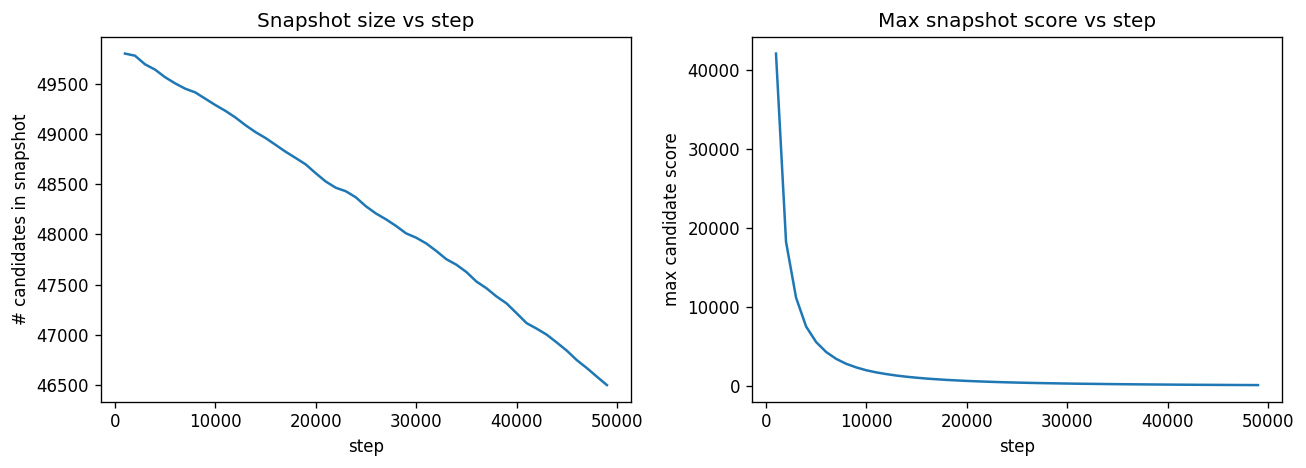

In [2]:
# --- Single cell: number of candidates & max score per snapshot ---

import json
from pathlib import Path

# >>> EDIT THIS PATH <<<
TELEMETRY_JSON = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_count/bpe_count-telemetry.json"

# Optional plotting/table deps (code will still work without pandas)
import matplotlib.pyplot as plt

import pandas as pd
HAVE_PANDAS = True


# ---- Load telemetry ----
tel_path = Path(TELEMETRY_JSON)
if not tel_path.is_file():
    raise SystemExit(f"❌ Telemetry file not found: {tel_path}")

with open(tel_path, "r", encoding="utf-8") as f:
    telemetry = json.load(f)

snaps = telemetry.get("score_snapshots", [])
if not snaps:
    raise SystemExit("ℹ️ No 'score_snapshots' in telemetry (nothing to summarize).")

# Some dumps might not be sorted; enforce by step
snaps = sorted(snaps, key=lambda s: s.get("step", 0))

rows = []  # (step, n_items, max_score)
for i, s in enumerate(snaps):
    step = int(s.get("step", i))
    items = s.get("items", []) or []
    n_items = len(items)
    # items: [{ "pair": [id_a, id_b] or (id_a,id_b), "score": float, "count": int}, ...]
    if n_items > 0:
        # be robust to missing/None
        max_score = max(float(it.get("score", float("-inf"))) for it in items)
    else:
        max_score = float("nan")
    rows.append((step, n_items, max_score))

# Preview
print(f"Snapshots: {len(rows)}")
print("First 5:")
for r in rows[:20]:
    print(f"  step={r[0]:>6}  n_items={r[1]:>7}  max_score={r[2]:.6g}")
print("Last 5:")
for r in rows[-20:]:
    print(f"  step={r[0]:>6}  n_items={r[1]:>7}  max_score={r[2]:.6g}")

# Optional: show as a small table and plots
if HAVE_PANDAS:
    import numpy as np
    df = pd.DataFrame(rows, columns=["step", "n_items", "max_score"])
    display(df.head(), df.tail())

    # Two simple line plots
    fig = plt.figure(figsize=(11, 4), dpi=120)
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(df["step"], df["n_items"])
    ax1.set_xlabel("step")
    ax1.set_ylabel("# candidates in snapshot")
    ax1.set_title("Snapshot size vs step")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot(df["step"], df["max_score"])
    ax2.set_xlabel("step")
    ax2.set_ylabel("max candidate score")
    ax2.set_title("Max snapshot score vs step")

    fig.tight_layout()
    plt.show()
else:
    print("\n(pandas not installed — skipping table/plots)")

In [4]:
import json
from pathlib import Path
from typing import Dict, Tuple, List, Optional
import matplotlib.pyplot as plt

# === Inputs (edit these) ===
TEL_PATH = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_approx_ll/bpe_approx_ll-telemetry.json"
TOKENIZER_JSON: Optional[str] = "/Users/ahmetcanyavuz/Developer/tokenizers/results_50k/bpe_approx_ll/bpe_approx_ll-tokenizer.json"
TARGET_PAIR: Optional[Tuple[int, int]] = (166, 83)   # set None to use merge_trace[0]

# --- helpers ---
def load_id2tok(tokenizer_json_path: Optional[str]) -> Dict[int, str]:
    if not tokenizer_json_path:
        return {}
    with open(tokenizer_json_path, "r") as f:
        tj = json.load(f)
    # wordlevel-like vocab dict: token->id
    vocab = tj.get("model", {}).get("vocab", {})
    # some versions store list of [token, id]
    if isinstance(vocab, list):
        # GPT2-like format occasionally appears; normalize
        id2tok = {int(id_): str(tok) for tok, id_ in vocab}
    else:
        id2tok = {int(id_): str(tok) for tok, id_ in vocab.items()}
    return id2tok

def decode_pair(pair: Tuple[int,int], id2tok: Dict[int,str]) -> str:
    a, b = pair
    ta = id2tok.get(a, f"<{a}>")
    tb = id2tok.get(b, f"<{b}>")
    return f"({a}:{ta!r}, {b}:{tb!r})"

def find_pair_in_snapshots(tel: dict, pair: Tuple[int,int]) -> List[Tuple[int, float, float]]:
    """Return list of (step, score, count) where `pair` appears in snapshot items."""
    hits = []
    snaps = sorted(tel.get("score_snapshots", []), key=lambda s: s.get("step", 0))
    for s in snaps:
        step = int(s.get("step", 0))
        items = s.get("items", [])
        for it in items:
            p = tuple(it.get("pair", []))
            if p == pair:
                score = float(it.get("score", 0.0))
                count = float(it.get("count", 0.0))
                hits.append((step, score, count))
    return hits

def plot_pair_counts(hits: List[Tuple[int,float,float]], title: str):
    if not hits:
        print("No occurrences to plot.")
        return
    steps = [h[0] for h in hits]
    counts = [h[2] for h in hits]
    plt.figure(figsize=(9,4), dpi=120)
    plt.plot(steps, counts, marker="o")
    plt.xlabel("snapshot step")
    plt.ylabel("count (raw pair frequency)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- load telemetry & (optionally) tokenizer.json for decoding ---
with open(TEL_PATH, "r") as f:
    tel = json.load(f)

id2tok = load_id2tok(TOKENIZER_JSON)

# Step-0 pair from this *same* telemetry file
merge_trace = tel.get("merge_trace", [])
if not merge_trace:
    raise SystemExit("No merge_trace in telemetry; cannot check first merge.")

first_pair = tuple(merge_trace[0].get("pair", []))
first_count = merge_trace[0].get("count", None)
print(f"First accepted merge (from this file): pair={first_pair}  count={first_count}")
if id2tok:
    print("  decoded:", decode_pair(first_pair, id2tok))

# If TARGET_PAIR not provided, use the first accepted pair
PAIR = TARGET_PAIR or first_pair
print(f"\nTracking pair {PAIR}")
if id2tok:
    print("  decoded:", decode_pair(PAIR, id2tok))

# 1) Where does PAIR appear in snapshots?
hits = find_pair_in_snapshots(tel, PAIR)
if not hits:
    print("  → Pair not found in ANY snapshots.")
else:
    print(f"  → Found in {len(hits)} snapshot(s):")
    for step, score, count in hits[:12]:
        print(f"     - step={step:>6}  score={score:.6g}  count={int(count)}")
    if len(hits) > 12:
        print(f"     ... and {len(hits)-12} more")

    plot_pair_counts(hits, title=f"Pair {PAIR} count across snapshots")

# 2) Sanity check: the step-0 pair should NOT appear after step 0
first_hits = find_pair_in_snapshots(tel, first_pair)
bad_hits = [h for h in first_hits if h[0] > 0]
if bad_hits:
    print("\n⚠️  Sanity check FAILED: the step‑0 merge pair appears in later snapshots.")
    for step, score, count in bad_hits[:12]:
        print(f"     step={step}  score={score:.6g}  count={int(count)}")
    print("   This suggests file mismatch or a snapshotting bug.")
else:
    # If we don’t snapshot at step 0 (common), seeing none is expected.
    print("\n✓ Sanity check: step‑0 pair does not appear in later snapshots.")

First accepted merge (from this file): pair=(83, 71)  count=9852298
  decoded: (83:'t', 71:'h')

Tracking pair (166, 83)
  decoded: (166:'Ġ', 83:'t')
  → Pair not found in ANY snapshots.

✓ Sanity check: step‑0 pair does not appear in later snapshots.
